In [1]:
import numpy as np
import pandas as pd
import jax
default_device = jax.devices("gpu")[0]
jax.config.update("jax_default_device", default_device)

import jax.numpy as jnp
import jax.random as jr
import optax
import time
import matplotlib.pyplot as plt

from magi import MAGI, clear_jax_cache
from tests import *

In [2]:
clear_jax_cache()

cleared 1840 entries, 102.2 MB from /home/jamie/storage-1/github-repos/magi_msvgd/magi_msvgd/.jax_cache


('/home/jamie/storage-1/github-repos/magi_msvgd/magi_msvgd/.jax_cache',
 1840,
 102234626)

In [3]:
model = FitzHughNagumo
model.ground_truth()

t, sample = model.sample(seed=0)

data = model.discretize(t, sample)

In [6]:
dtype = jnp.float32
device = jax.devices('gpu')[0]

start = time.time()
solver = MAGI(model.ode, data, model.hyperparams['theta'], theta_prec=jnp.ones(model.hyperparams['theta'].shape)*1e-3, sigmas=model.hyperparams['sigma'], init_device=device)

solver.put(dtype, device)
end = time.time()
print(f"Initialization time: {end - start:.4f}")

start = time.time()
with jax.default_device(device):
    solver.fit(inner_iters=10)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Initialization time: 0.7167
MAGI posterior  --  profiled mixture: states integrated out, parameters integrated over 512 nodes

  diagnostic                      value     required         what it measures
  --------------------------------------------------------------------------------------------------------
  effective sample size     394 (76.9%)       >= 10%   OK    concentration of the importance weights; below this the
                                                               estimate is dominated by a handful of nodes
  Pareto k-hat                    -0.62       < 0.70   OK    tail heaviness of the importance ratios; above this
                                                               the weighted variance is not reliable
  failed profile solves         0 / 512            0   OK    nodes whose inner solve diverged or gave an
                                                               indefinite state Hessian; these are dropped
  null directions                     

In [7]:
diagnostics = solver.diagnose()

MAGI diagnosis  --  d = 325, p = 3, 1.0 s, no sampling

  check                           value     required         what it measures
  --------------------------------------------------------------------------------------------------------
  distance to the mode          2.5e-03      < 1e-02   OK    sqrt(g' H^-1 g): how far this point is from the
                                                               true mode, in posterior sd. Unitless, so it
                                                               means the same across problems and dtypes
  gradient norm                 4.4e-02           --   info  the raw ||grad log p||, for reference. It carries
                                                               units and its floor is set by the working
                                                               precision, so it is not thresholded here
  negative curvature                  0            0   OK    directions in which the mode is a saddle, not a
         

In [ ]:
Xs, thetas, sigmas = solver.sample(k=2_000)

with jax.default_device(jax.devices('cpu')[0]):
    Xs, thetas, sigmas = solver.nuts()

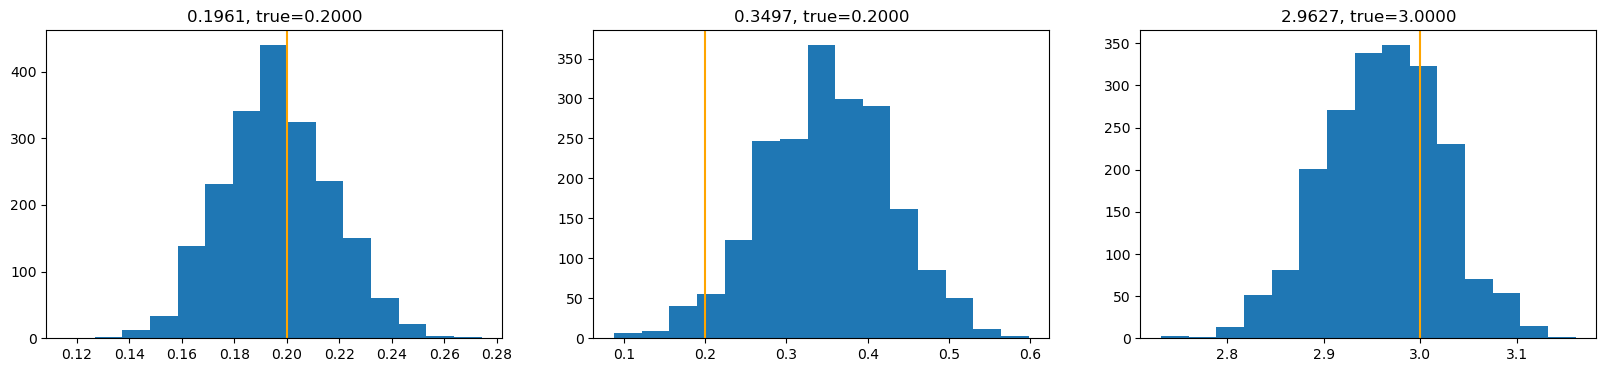

In [42]:
fig, ax = plt.subplots(1, thetas.shape[1], figsize=(20, 4))
for i in range(thetas.shape[1]):
    ax[i].hist(thetas[:,i], bins=15)
    ax[i].set_title(f"{thetas[:,i].mean():.4f}, true={model.hyperparams['theta'][i]:.4f}")
    ax[i].axvline(model.hyperparams['theta'][i], color='orange')

plt.show()

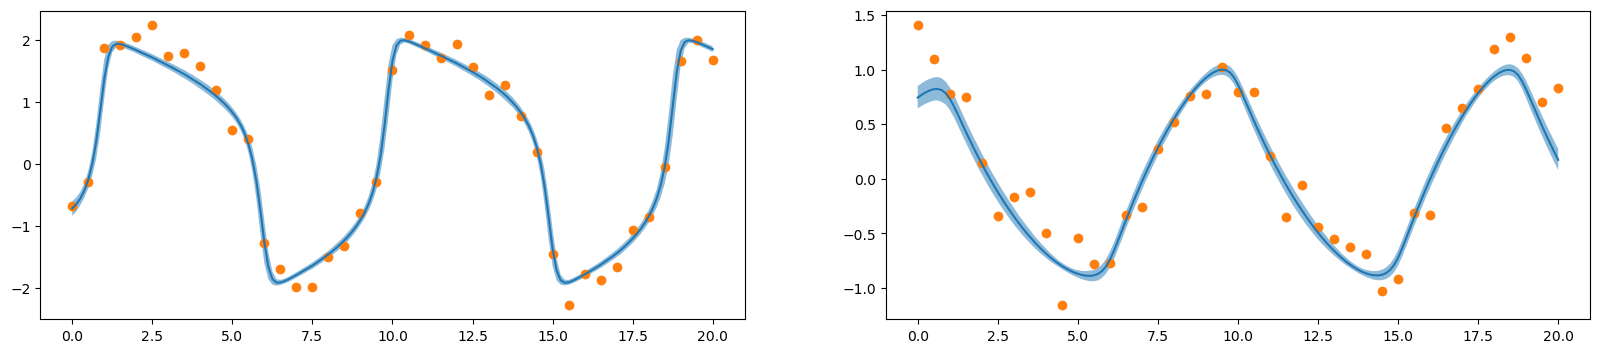

In [44]:
lower_q = 0.025
upper_q = 0.975

obs_data = jnp.where(solver.tau, solver.x_init, jnp.nan)
# lower_q = 0.0
# upper_q = 1.0

fig, ax = plt.subplots(1, Xs.shape[-1], figsize=(20, 4))

for i in range(Xs.shape[-1]):
    ax[i].fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,i], lower_q, axis=0), jnp.quantile(Xs[:,:,i], upper_q, axis=0), alpha=0.5)
    # ax[i].plot(solver.I, model.truth_at(jnp.round(solver.I, 3))[:,:,i])
    ax[i].plot(solver.I, Xs.mean(axis=0)[:,i])
    ax[i].scatter(solver.I, obs_data[:,i])

plt.show()

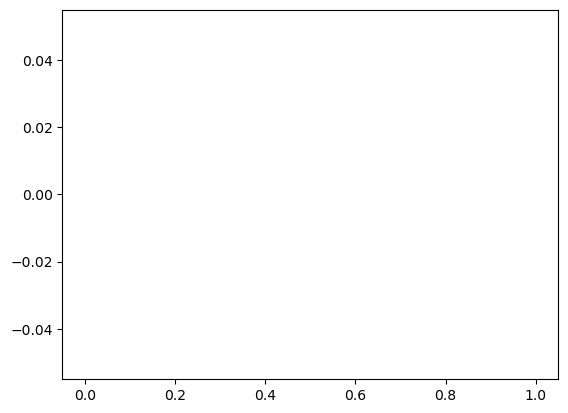

In [24]:
plt.hist(sigmas)
plt.show()